In [1]:
import warnings 
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.io.fits.verify import VerifyWarning


In [2]:
warnings.filterwarnings("ignore", category=VerifyWarning)

In [3]:
RSRadialProfile_File = 'RSRadialProfile.fits'

In [4]:
with fits.open(RSRadialProfile_File, ignore_missing_end=True) as hdu_list:
    hdu_list.verify('silentfix')
    hist_dataReverseShock = hdu_list[1].data

# Grab the radius values
radiusRS = hist_dataReverseShock['RMID']


# Need to convert from pixels to arcsec using plate scale
radiusRS = radiusRS * 0.492


# Grab the angle values
angleRS = hist_dataReverseShock['ROTANG']
angleRS = angleRS[:, 0]


# Grab the counts values given in photons/pixel**2
countsRS = hist_dataReverseShock['SUR_BRI']


In [5]:
radlistRS = []
countslistRS = []

for theta, rad, flux in zip(np.round(angleRS,0), radiusRS, countsRS):
    if theta == 144:
        radlistRS.append(rad)
        countslistRS.append(flux)

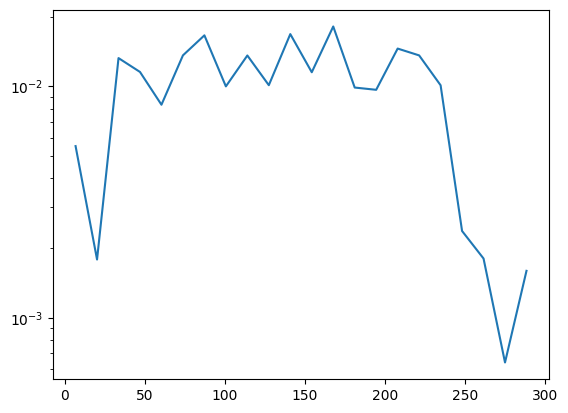

In [6]:
plt.plot(radlistRS, countslistRS)
plt.yscale('log')
plt.show()

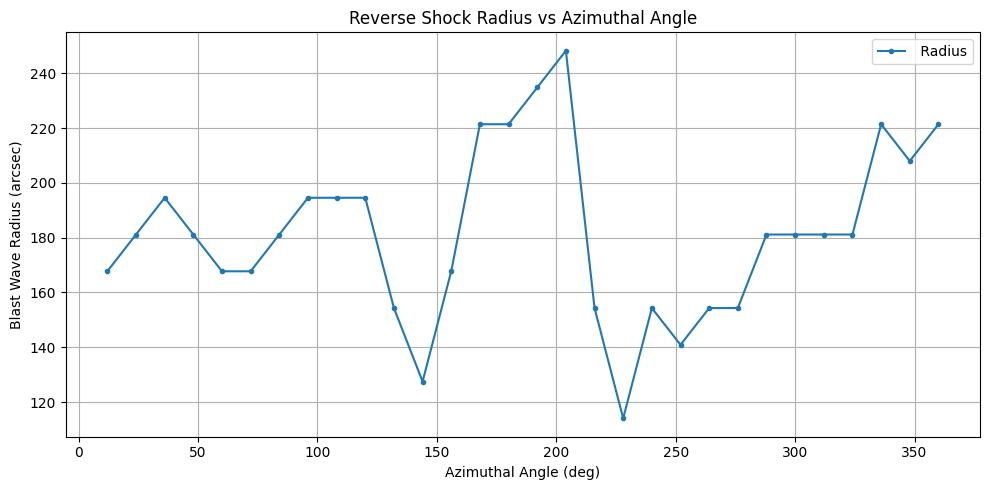

In [8]:
# Round angles to avoid floating point issues
rounded_angles = np.round(angleRS[1:31], 2)
radii = radiusRS[::30]
# print(len(radii), radii)

reverse_shock_radii = []
angle_list = []

for i, theta in enumerate(rounded_angles):

    f_vals = countsRS[i::30]
    # print(len(f_vals))

    r_RS = radii[np.argmax(f_vals)]
    reverse_shock_radii.append(r_RS)
    angle_list.append(theta)

# Final arrays
angle_array = np.array(angle_list)
reverse_shock_array = np.array(reverse_shock_radii)


# Plot
plt.figure(figsize=(10, 5))
plt.plot(angle_array, reverse_shock_array, '.-', label=' Radius')
plt.xlabel("Azimuthal Angle (deg)")
plt.ylabel("Blast Wave Radius (arcsec)")
plt.title("Reverse Shock Radius vs Azimuthal Angle")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()